## 读数据和基础准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/online_retail_clean.csv")
df.head()

,invoice_no,stockcode,description,quantity,invoice_date,unit_price,customer_id,country,source_sheet,is_cancellation,sales_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010,False,30.0


In [2]:
df.shape

(805549, 11)

In [3]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

df["year"] = df["invoice_date"].dt.year
df["month"] = df["invoice_date"].dt.month
df["day"] = df["invoice_date"].dt.day
df["hour"] = df["invoice_date"].dt.hour
df["year_month"] = df["invoice_date"].dt.to_period("M").astype(str)
df["weekday"] = df["invoice_date"].dt.day_name()

df.head()

,invoice_no,stockcode,description,quantity,invoice_date,unit_price,customer_id,country,source_sheet,is_cancellation,sales_amount,year,month,day,hour,year_month,weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010,False,83.4,2009,12,1,7,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0,2009,12,1,7,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0,2009,12,1,7,2009-12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010,False,100.8,2009,12,1,7,2009-12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010,False,30.0,2009,12,1,7,2009-12,Tuesday


## Summary

In [4]:
summary = {
    "rows": len(df),
    "customers": df["customer_id"].nunique(),
    "orders": df["invoice_no"].nunique(),
    "products": df["stockcode"].nunique(),
    "countries": df["country"].nunique(),
    "total_sales": df["sales_amount"].sum(),
    "avg_order_value_proxy": df.groupby("invoice_no")["sales_amount"].sum().mean()
}

summary

{'rows': 805549,
 'customers': 5878,
 'orders': 36969,
 'products': 4631,
 'countries': 41,
 'total_sales': 17743429.178000003,
 'avg_order_value_proxy': 479.9542637885796}

In [5]:
summary_df = pd.DataFrame([summary])
summary_df

,rows,customers,orders,products,countries,total_sales,avg_order_value_proxy
0,805549,5878,36969,4631,41,1.774343e+07,479.954264


## 看月销售趋势

In [6]:
monthly_sales = (
    df.groupby("year_month", as_index=False)["sales_amount"]
    .sum()
)

monthly_sales

,year_month,sales_amount
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192
5,2010-05,599985.790
6,2010-06,639066.580
7,2010-07,591636.740
8,2010-08,604242.650
9,2010-09,831615.001


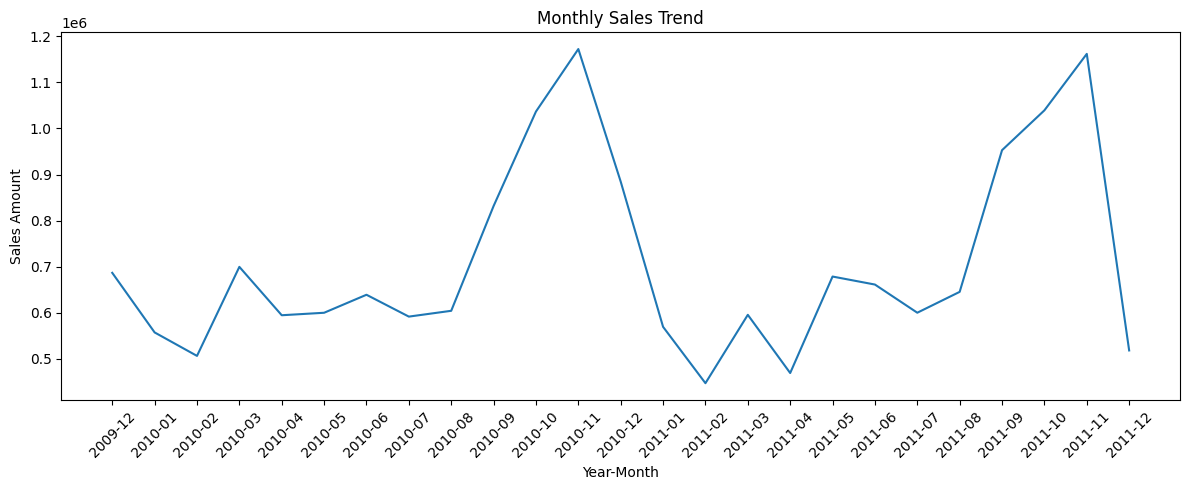

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["year_month"], monthly_sales["sales_amount"])
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

In [8]:
monthly_orders = (
    df.groupby("year_month", as_index=False)["invoice_no"]
    .nunique()
    .rename(columns={"invoice_no": "order_count"})
)

monthly_orders

,year_month,order_count
0,2009-12,1512
1,2010-01,1011
2,2010-02,1104
3,2010-03,1524
4,2010-04,1329
5,2010-05,1377
6,2010-06,1497
7,2010-07,1381
8,2010-08,1293
9,2010-09,1689


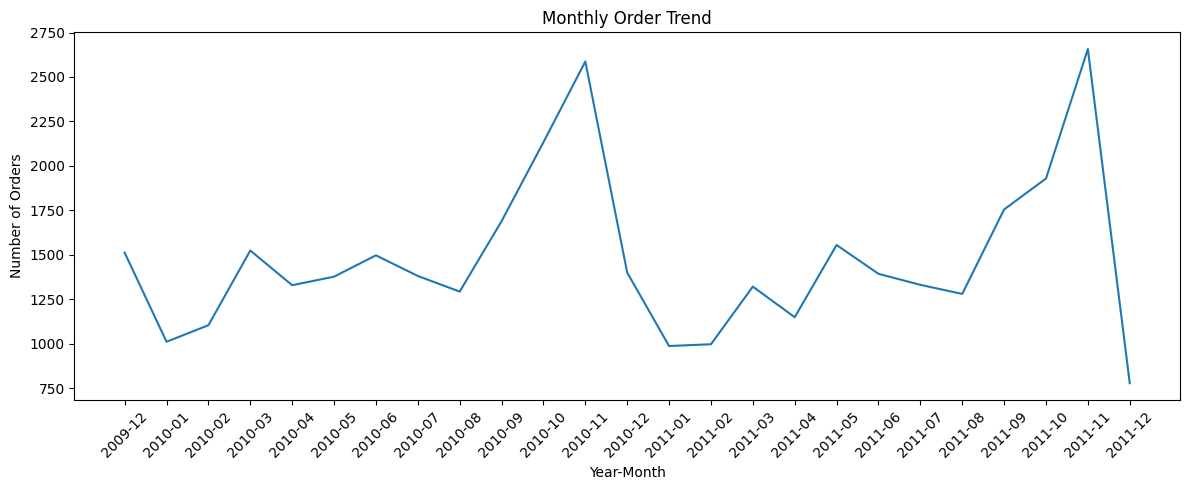

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["year_month"], monthly_orders["order_count"])
plt.xticks(rotation=45)
plt.title("Monthly Order Trend")
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [10]:
monthly_customers = (
    df.groupby("year_month", as_index=False)["customer_id"]
    .nunique()
    .rename(columns={"customer_id": "active_customers"})
)

monthly_customers

,year_month,active_customers
0,2009-12,955
1,2010-01,720
2,2010-02,772
3,2010-03,1057
4,2010-04,942
5,2010-05,966
6,2010-06,1041
7,2010-07,928
8,2010-08,911
9,2010-09,1145


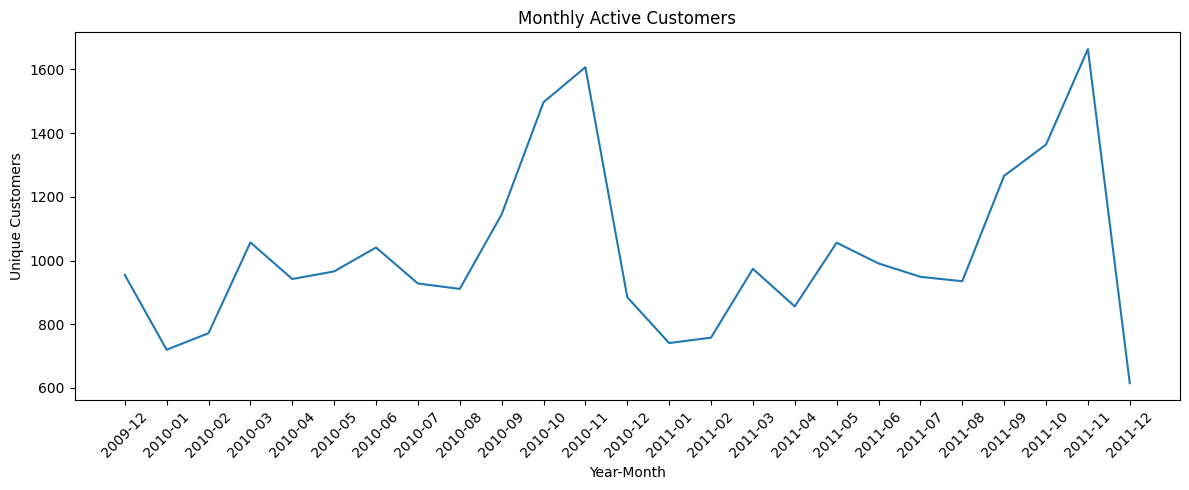

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_customers["year_month"], monthly_customers["active_customers"])
plt.xticks(rotation=45)
plt.title("Monthly Active Customers")
plt.xlabel("Year-Month")
plt.ylabel("Unique Customers")
plt.tight_layout()
plt.show()

## 看国家维度

In [12]:
country_sales = (
    df.groupby("country", as_index=False)["sales_amount"]
    .sum()
    .sort_values("sales_amount", ascending=False)
)

country_sales.head(10)

,country,sales_amount
38,United Kingdom,1.472315e+07
10,EIRE,6.216311e+05
24,Netherlands,5.542323e+05
14,Germany,4.312625e+05
13,France,3.552575e+05
0,Australia,1.699681e+05
32,Spain,1.091785e+05
34,Switzerland,1.003653e+05
33,Sweden,9.154972e+04
9,Denmark,6.986219e+04


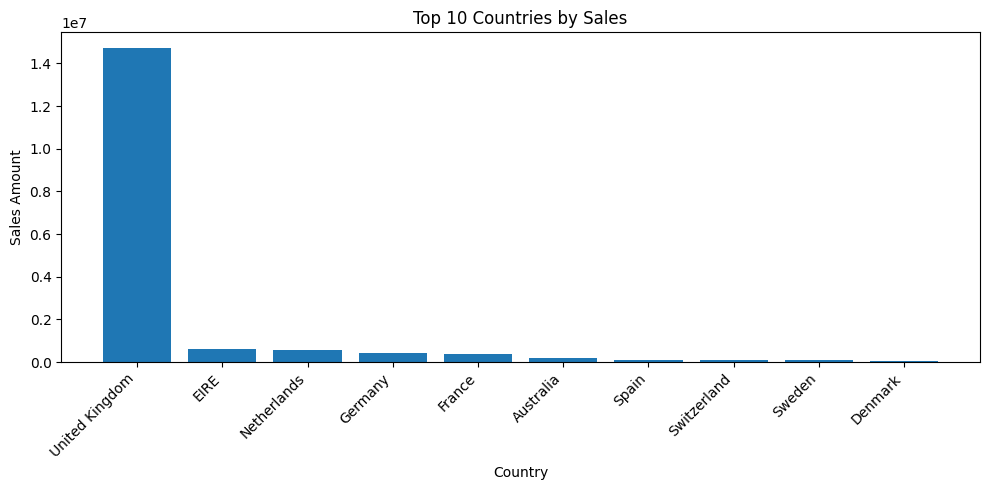

In [13]:
top10_country_sales = country_sales.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_country_sales["country"], top10_country_sales["sales_amount"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

In [14]:
country_orders = (
    df.groupby("country", as_index=False)["invoice_no"]
    .nunique()
    .rename(columns={"invoice_no": "order_count"})
    .sort_values("order_count", ascending=False)
)

country_orders.head(10)

,country,order_count
38,United Kingdom,33541
14,Germany,789
13,France,614
10,EIRE,567
24,Netherlands,228
32,Spain,154
3,Belgium,149
33,Sweden,104
0,Australia,95
28,Portugal,93


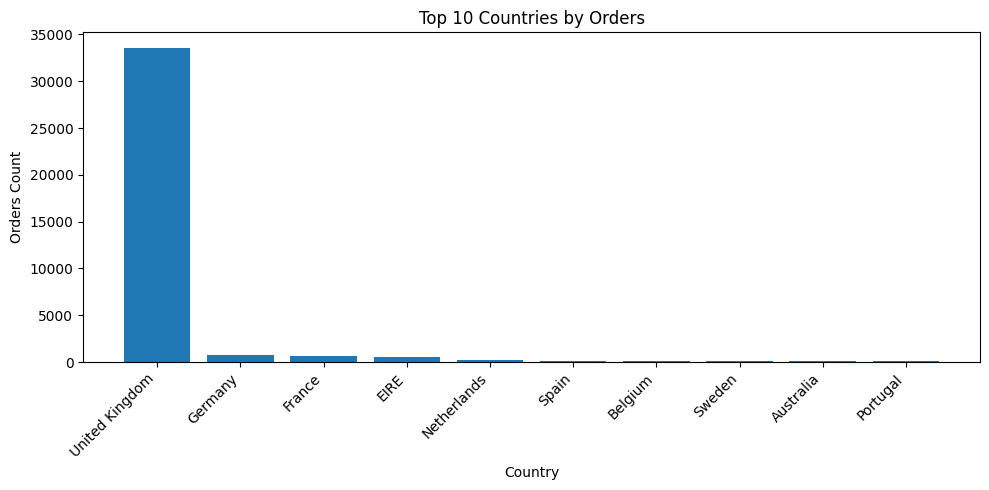

In [15]:
top10_country_orders = country_orders.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_country_orders["country"], top10_country_orders["order_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Orders Count")
plt.tight_layout()
plt.show()

In [16]:
country_customers = (
    df.groupby("country", as_index=False)["customer_id"]
    .nunique()
    .rename(columns={"customer_id": "customer_count"})
    .sort_values("customer_count", ascending=False)
)

country_customers.head(10)

,country,customer_count
38,United Kingdom,5350
14,Germany,107
13,France,95
32,Spain,41
3,Belgium,29
28,Portugal,24
24,Netherlands,22
34,Switzerland,22
33,Sweden,19
18,Italy,17


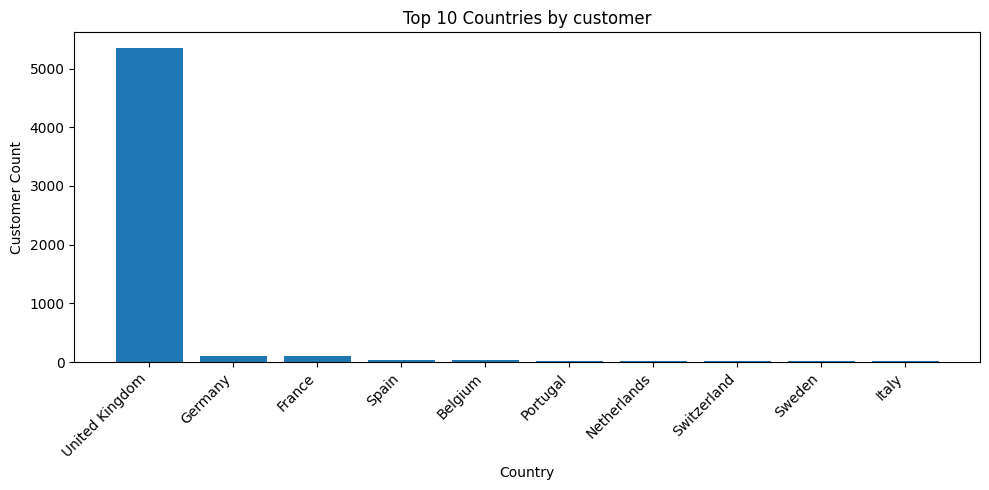

In [17]:
top10_country_customer = country_customers.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_country_customer["country"], top10_country_customer["customer_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by customer")
plt.xlabel("Country")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

## 看商品表现

销量最多

In [18]:
product_qty = (
    df.groupby(["stockcode", "description"], as_index=False)["quantity"]
    .sum()
    .sort_values("quantity", ascending=False)
)

product_qty.head(10)

,stockcode,description,quantity
4031,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,109169
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93640
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,79913
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
4725,85099B,JUMBO BAG RED RETROSPOT,75759
115,17003,BROCADE RING PURSE,71129
1357,21977,PACK OF 60 PINK PAISLEY CAKE CASES,55270
4595,84991,60 TEATIME FAIRY CAKE CASES,53495
659,21212,PACK OF 72 RETROSPOT CAKE CASES,46107


销售额前 10

In [19]:
product_sales = (
    df.groupby(["stockcode", "description"], as_index=False)["sales_amount"]
    .sum()
    .sort_values("sales_amount", ascending=False)
)

product_sales.head(10)

,stockcode,description,sales_amount
1862,22423,REGENCY CAKESTAND 3 TIER,286486.30
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,252072.46
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5309,M,Manual,152340.57
4725,85099B,JUMBO BAG RED RETROSPOT,136980.08
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,127074.17
5311,POST,POSTAGE,126563.04
3627,47566,PARTY BUNTING,103880.23
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33


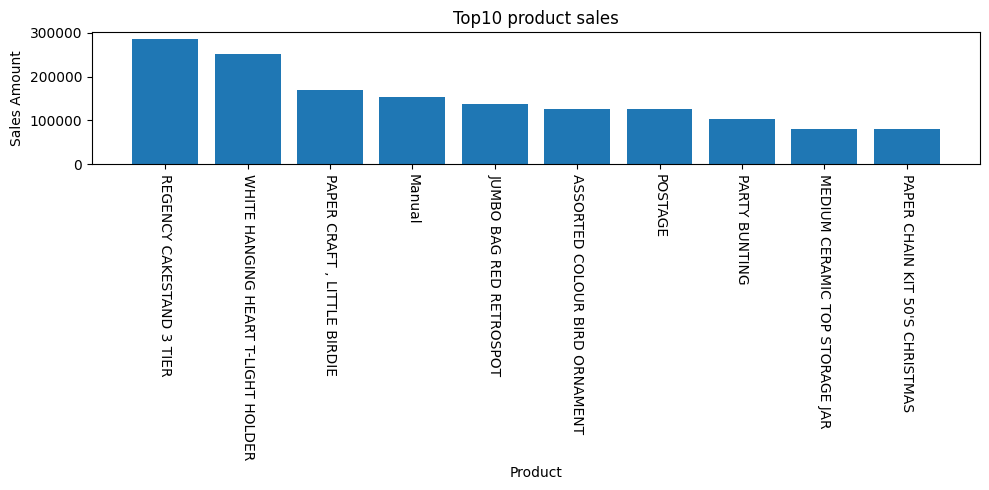

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(product_sales.head(10)["description"], product_sales.head(10)["sales_amount"])
plt.xticks(rotation=270)
plt.title("Top10 product sales")
plt.xlabel("Product")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

## 客户价值分布

In [21]:
customer_summary = (
    df.groupby("customer_id",as_index=False)
    .agg(
        total_sales=("sales_amount", "sum"),
        total_orders=("invoice_no", "nunique"),
        total_items=("quantity", "sum"),
        avg_order_value=("sales_amount", "mean")
    )
)

customer_summary.head()

,customer_id,total_sales,total_orders,total_items,avg_order_value
0,12346.0,77556.46,12,74285,2281.072353
1,12347.0,5633.32,8,3286,22.266087
2,12348.0,2019.40,5,2714,39.596078
3,12349.0,4428.69,4,1624,25.306800
4,12350.0,334.40,1,197,19.670588


In [22]:
customer_summary.describe()

,customer_id,total_sales,total_orders,total_items,avg_order_value
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,3018.616737,6.289384,1821.396223,48.299996
std,1715.572666,14737.731040,13.009406,8963.011855,780.177864
min,12346.000000,2.950000,1.000000,1.000000,2.042182
25%,13833.250000,348.762500,1.000000,190.000000,11.470705
50%,15314.500000,898.915000,3.000000,491.500000,17.354064
75%,16797.750000,2307.090000,7.000000,1376.000000,24.195021
max,18287.000000,608821.650000,398.000000,367193.000000,56157.500000


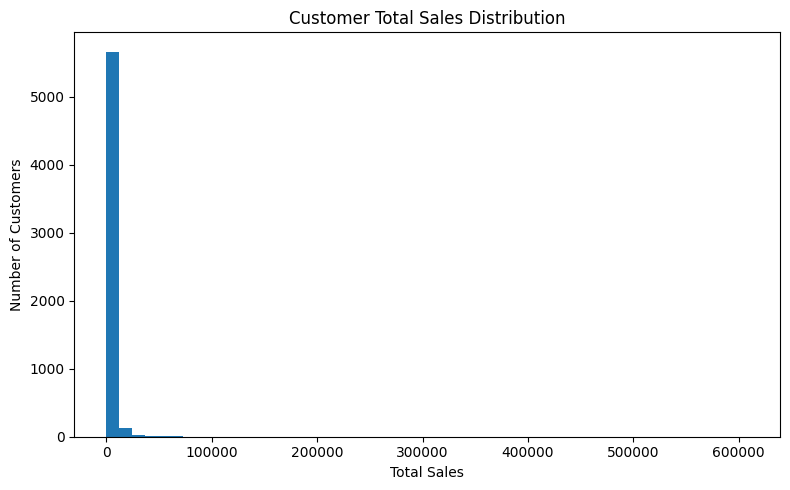

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(customer_summary["total_sales"], bins=50)
plt.title("Customer Total Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

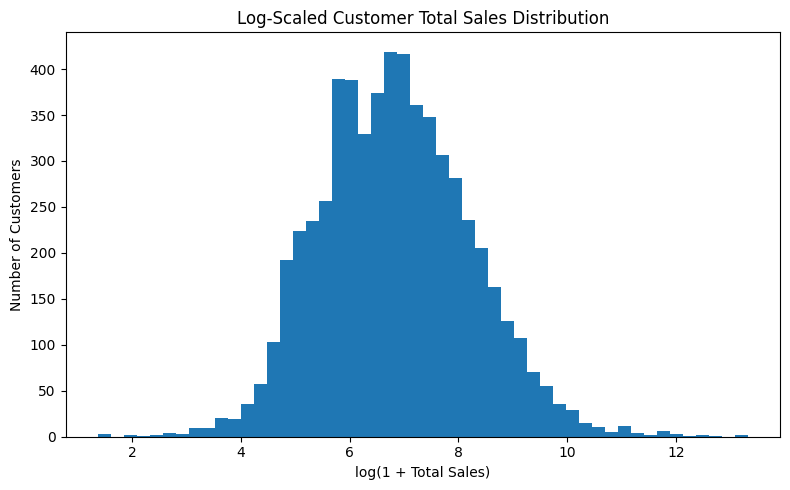

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(customer_summary["total_sales"]), bins=50)
plt.title("Log-Scaled Customer Total Sales Distribution")
plt.xlabel("log(1 + Total Sales)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### 高价值客户

In [25]:
customer_summary.sort_values("total_sales", ascending=False).head(10)

,customer_id,total_sales,total_orders,total_items,avg_order_value
5692,18102.0,608821.65,145,188340,575.445794
2277,14646.0,528602.52,151,367193,137.335027
1789,14156.0,313946.37,156,165992,77.555921
2538,14911.0,295972.63,398,149987,26.320376
5050,17450.0,246973.09,51,84720,582.483703
1331,13694.0,196482.81,143,189205,128.841187
5109,17511.0,175603.55,60,119656,91.890921
4061,16446.0,168472.50,2,80997,56157.500000
4295,16684.0,147142.77,55,104810,204.934220
68,12415.0,144458.37,28,91447,156.002559


## 订单行为

### 聚合订单

In [26]:
order_summary = (
    df.groupby("invoice_no", as_index=False)
    .agg(
        order_sales=("sales_amount", "sum"),
        order_items=("quantity", "sum"),
        unique_products=("stockcode", "nunique"),
        customer_id=("customer_id", "first"),
        country=("country", "first"),
        invoice_date=("invoice_date", "first")
    )
)

order_summary.head()

,invoice_no,order_sales,order_items,unique_products,customer_id,country,invoice_date
0,489434,505.30,166,8,13085.0,United Kingdom,2009-12-01 07:45:00
1,489435,145.80,60,4,13085.0,United Kingdom,2009-12-01 07:46:00
2,489436,630.33,193,19,13078.0,United Kingdom,2009-12-01 09:06:00
3,489437,310.75,145,23,15362.0,United Kingdom,2009-12-01 09:08:00
4,489438,2286.24,826,17,18102.0,United Kingdom,2009-12-01 09:24:00


### 订单金额分布

In [27]:
order_summary["order_sales"].describe()

count     36969.000000
mean        479.954264
std        1374.990573
min           0.380000
25%         160.800000
50%         305.250000
75%         489.260000
max      168469.600000
Name: order_sales, dtype: float64

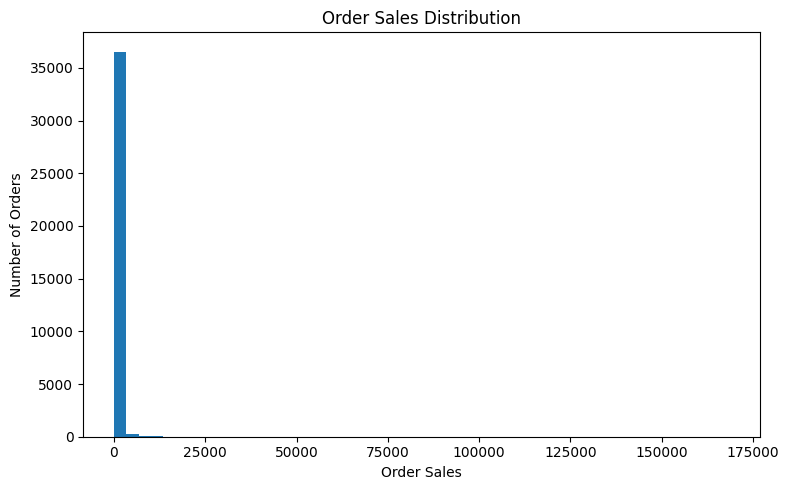

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(order_summary["order_sales"], bins=50)
plt.title("Order Sales Distribution")
plt.xlabel("Order Sales")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

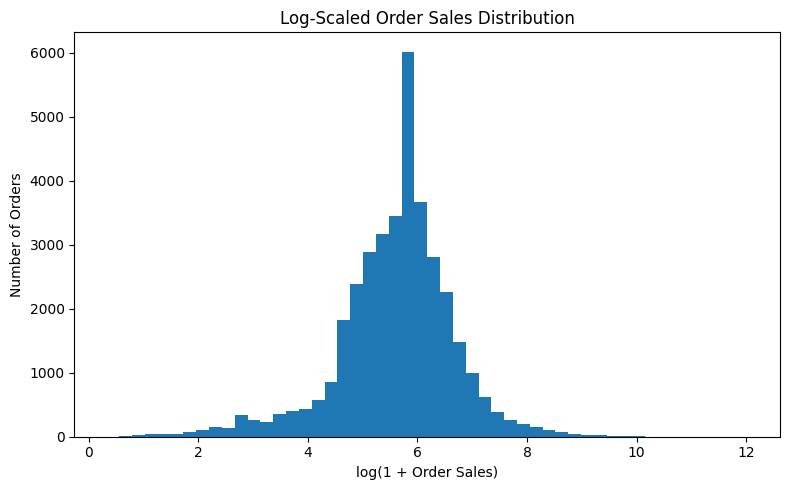

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(order_summary["order_sales"]), bins=50)
plt.title("Log-Scaled Order Sales Distribution")
plt.xlabel("log(1 + Order Sales)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [30]:
order_summary["unique_products"].describe()

count    36969.000000
mean        20.797560
std         22.399873
min          1.000000
25%          6.000000
50%         15.000000
75%         27.000000
max        541.000000
Name: unique_products, dtype: float64

## 时间行为模式

### 按星期几

In [31]:
weekday_sales = (
    df.groupby("weekday", as_index=False)["sales_amount"]
    .sum()
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales["weekday"] = pd.Categorical(weekday_sales["weekday"], categories=weekday_order, ordered=True)
weekday_sales = weekday_sales.sort_values("weekday")

weekday_sales

,weekday,sales_amount
1,Monday,2817407.806
5,Tuesday,3384678.832
6,Wednesday,3115619.693
4,Thursday,3841082.962
0,Friday,2758423.493
2,Saturday,9803.050
3,Sunday,1816413.342


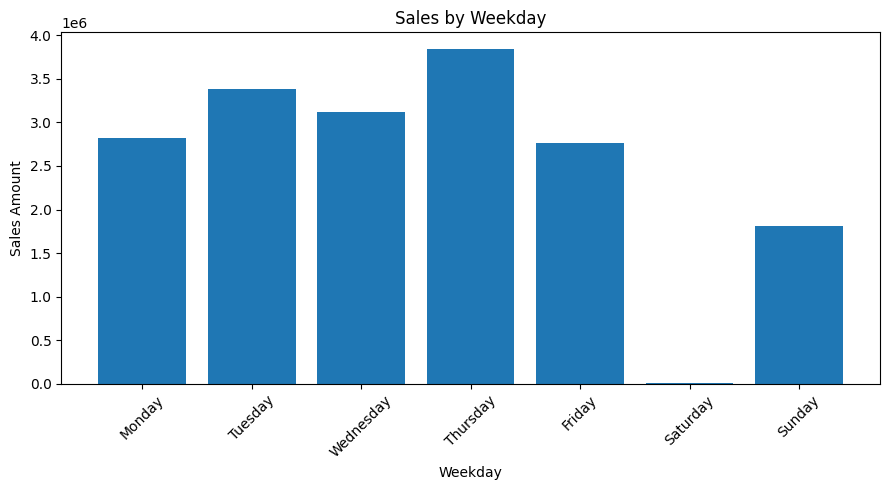

In [32]:
plt.figure(figsize=(9, 5))
plt.bar(weekday_sales["weekday"], weekday_sales["sales_amount"])
plt.xticks(rotation=45)
plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

### 按小时

In [33]:
hourly_sales = (
    df.groupby("hour", as_index=False)["sales_amount"]
    .sum()
)

hourly_sales

,hour,sales_amount
0,6,4.250
1,7,76212.570
2,8,528877.660
3,9,1509659.881
4,10,2360784.823
5,11,2271810.993
6,12,2750224.631
7,13,2401116.924
8,14,1995849.271
9,15,1882943.792


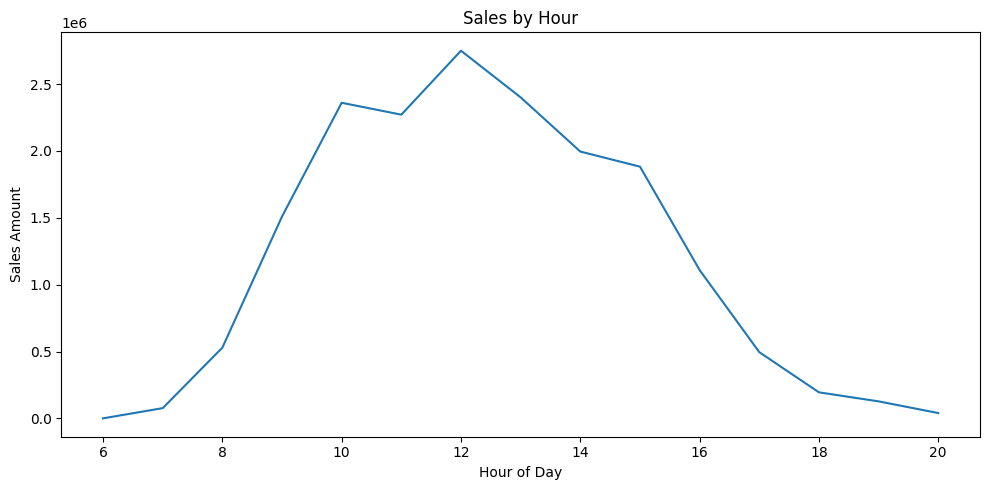

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_sales["hour"], hourly_sales["sales_amount"])
plt.title("Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

Revenue concentration / Pareto analysis

In [44]:
customer_sales_sorted = (
    customer_summary[["customer_id", "total_sales"]]
    .sort_values("total_sales", ascending=False)
    .reset_index(drop=True)
)

customer_sales_sorted["cum_sales"] = customer_sales_sorted["total_sales"].cumsum()
customer_sales_sorted["cum_sales_pct"] = customer_sales_sorted["cum_sales"] / customer_sales_sorted["total_sales"].sum()
customer_sales_sorted["customer_pct"] = (customer_sales_sorted.index + 1) / len(customer_sales_sorted)

customer_sales_sorted.head()

,customer_id,total_sales,cum_sales,cum_sales_pct,customer_pct
0,18102.0,608821.65,608821.65,0.034313,0.000170
1,14646.0,528602.52,1137424.17,0.064104,0.000340
2,14156.0,313946.37,1451370.54,0.081798,0.000510
3,14911.0,295972.63,1747343.17,0.098478,0.000681
4,17450.0,246973.09,1994316.26,0.112397,0.000851


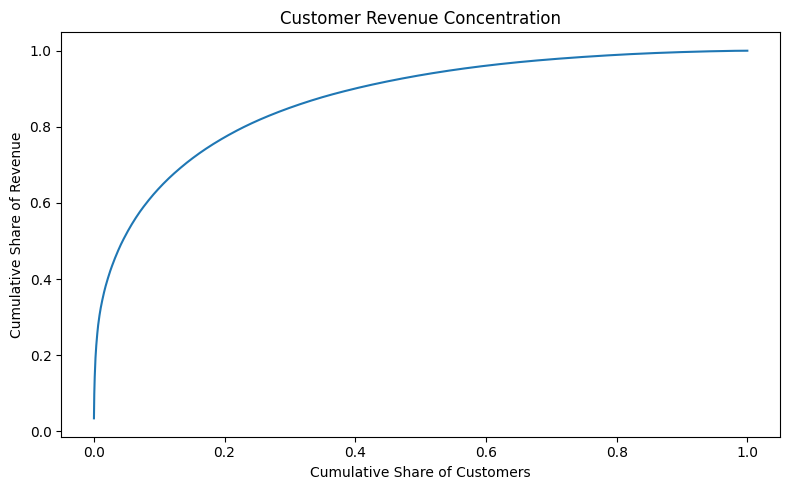

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(customer_sales_sorted["customer_pct"], customer_sales_sorted["cum_sales_pct"])
plt.title("Customer Revenue Concentration")
plt.xlabel("Cumulative Share of Customers")
plt.ylabel("Cumulative Share of Revenue")
plt.tight_layout()
plt.show()

In [46]:
share_20pct_customers = customer_sales_sorted.loc[
    customer_sales_sorted["customer_pct"] <= 0.2, "total_sales"
].sum() / customer_sales_sorted["total_sales"].sum()

share_20pct_customers

0.7724241516962986

商品收入集中度

In [47]:
product_sales_sorted = (
    product_sales[["stockcode", "description", "sales_amount"]]
    .sort_values("sales_amount", ascending=False)
    .reset_index(drop=True)
)

product_sales_sorted["cum_sales"] = product_sales_sorted["sales_amount"].cumsum()
product_sales_sorted["cum_sales_pct"] = product_sales_sorted["cum_sales"] / product_sales_sorted["sales_amount"].sum()
product_sales_sorted["product_pct"] = (product_sales_sorted.index + 1) / len(product_sales_sorted)

product_sales_sorted.head()

,stockcode,description,sales_amount,cum_sales,cum_sales_pct,product_pct
0,22423,REGENCY CAKESTAND 3 TIER,286486.30,286486.30,0.016146,0.000188
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,252072.46,538558.76,0.030353,0.000376
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,707028.36,0.039847,0.000564
3,M,Manual,152340.57,859368.93,0.048433,0.000753
4,85099B,JUMBO BAG RED RETROSPOT,136980.08,996349.01,0.056153,0.000941


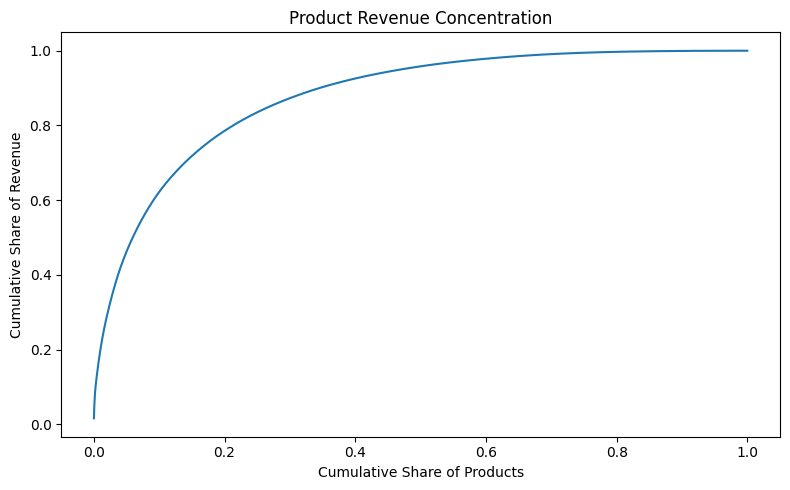

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(product_sales_sorted["product_pct"], product_sales_sorted["cum_sales_pct"])
plt.title("Product Revenue Concentration")
plt.xlabel("Cumulative Share of Products")
plt.ylabel("Cumulative Share of Revenue")
plt.tight_layout()
plt.show()

In [49]:
share_20pct_products = product_sales_sorted.loc[
    product_sales_sorted["product_pct"] <= 0.2, "sales_amount"
].sum() / product_sales_sorted["sales_amount"].sum()

share_20pct_products

0.7855153899608842

Repeat purchase behavior

In [50]:
repeat_behavior = (
    customer_summary[["customer_id", "total_orders"]]
    .copy()
)

repeat_behavior["is_repeat_customer"] = repeat_behavior["total_orders"] > 1
repeat_behavior["is_repeat_customer"].value_counts(normalize=True)

is_repeat_customer
True     0.723886
False    0.276114
Name: proportion, dtype: float64

repeat customer 比例：

In [51]:
repeat_customer_rate = repeat_behavior["is_repeat_customer"].mean()
repeat_customer_rate

0.7238856753997959

不同订单数分布：

In [52]:
customer_summary["total_orders"].describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: total_orders, dtype: float64

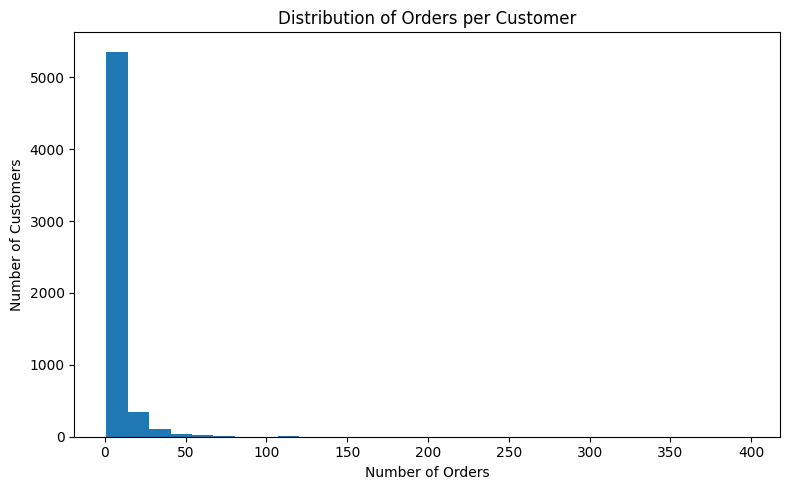

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(customer_summary["total_orders"], bins=30)
plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Business Insights

### Key exploratory findings

1. Sales, order volume, and active customer counts vary substantially over time, indicating seasonality and changing purchasing intensity. This suggests that recommendation and promotion strategies should be evaluated in a time-aware way rather than assuming stable customer behavior.
2. Revenue is concentrated in a limited number of countries, which points to priority markets for localized experimentation, merchandising, and personalized targeting. Country-level performance differences may also justify region-specific recommendation logic.
3. A relatively small subset of products contributes a disproportionate share of revenue, making them strong candidates for baseline recommendation, cross-sell entry points, and inventory prioritization.
4. Customer value is highly skewed, with a small portion of customers generating a large share of sales. This supports the use of customer segmentation to distinguish high-value, repeat, and lower-engagement users instead of applying uniform targeting strategies.
5. Order size and basket diversity vary meaningfully across transactions, suggesting that basket-based recommendation and product bundling could improve cross-sell performance and average order value.
6. The dataset structure naturally supports downstream segmentation, recommendation, and simulated experimentation workflows, making it suitable for prototyping personalization strategies in an e-commerce context.
7. Revenue concentration analysis shows that a relatively small share of customers and products drives a large portion of total sales, reinforcing the business value of prioritizing high-value customers and high-impact products in recommendation and campaign design.
8. A meaningful share of customers place multiple orders, indicating that repeat-purchase behavior can be modeled and leveraged for retention-focused segmentation and personalization strategies.
9. Top 20% customers → 77.2% of revenue
Top 20% products → 78.6% of revenue
Repeat customer rate → 72.4%

## Save resultats

### Tables

Save summary csv

In [35]:
summary_df.to_csv("../outputs/tables/eda_summary.csv", index=False)

Save country sales csv

In [36]:
country_sales.to_csv("../outputs/tables/country_sales.csv", index=False)

Save product sales csv

In [37]:
product_sales.to_csv("../outputs/tables/product_sales.csv", index=False)

Save order summary

In [38]:
order_summary.to_csv("../outputs/tables/order_summary.csv", index=False)

### Figures

Monthly Sales Trend

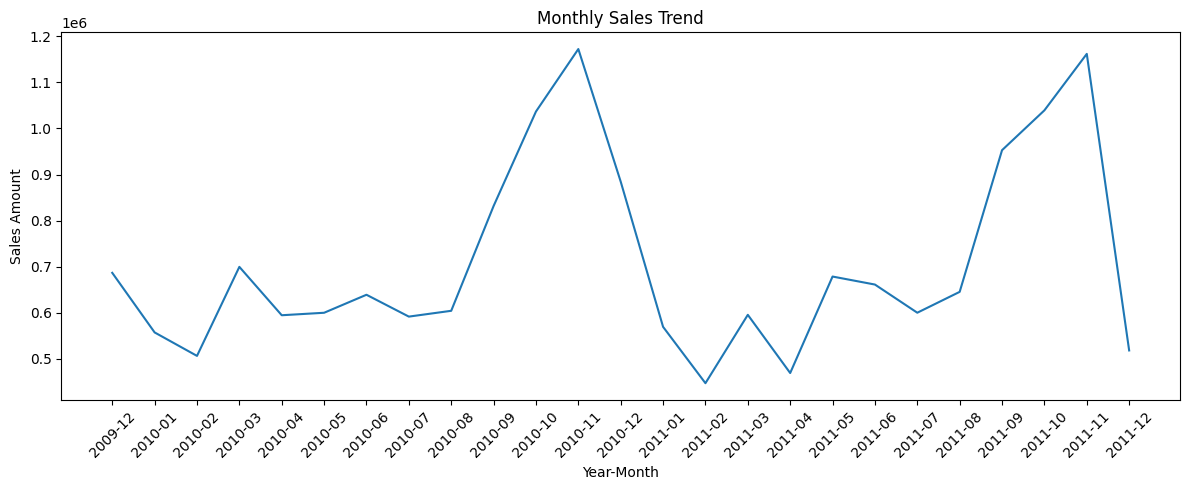

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["year_month"], monthly_sales["sales_amount"])
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()

Monthly orders trend

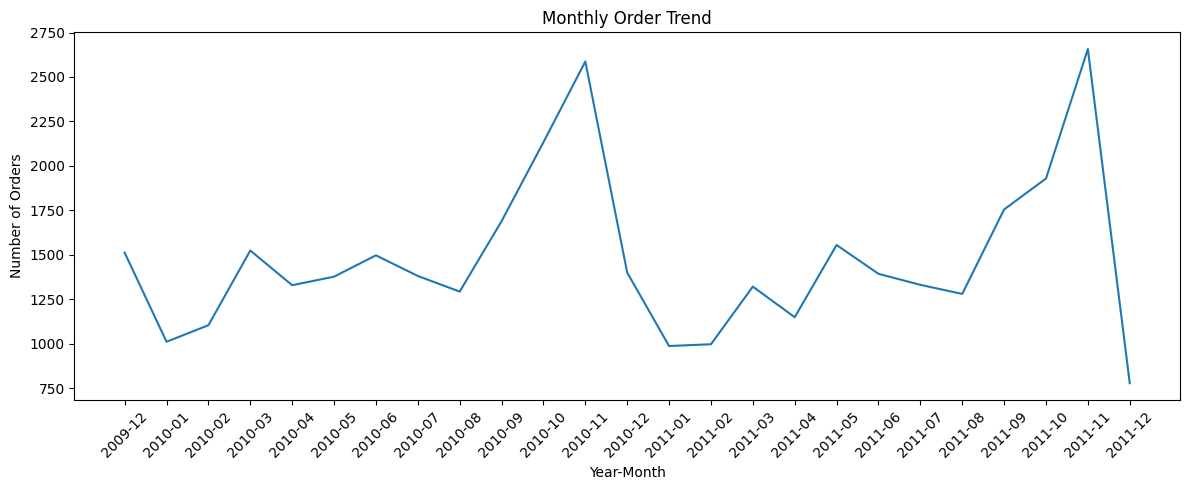

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["year_month"], monthly_orders["order_count"])
plt.xticks(rotation=45)
plt.title("Monthly Order Trend")
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_orders_trend.png", dpi=150, bbox_inches="tight")
plt.show()

Top10 country sales

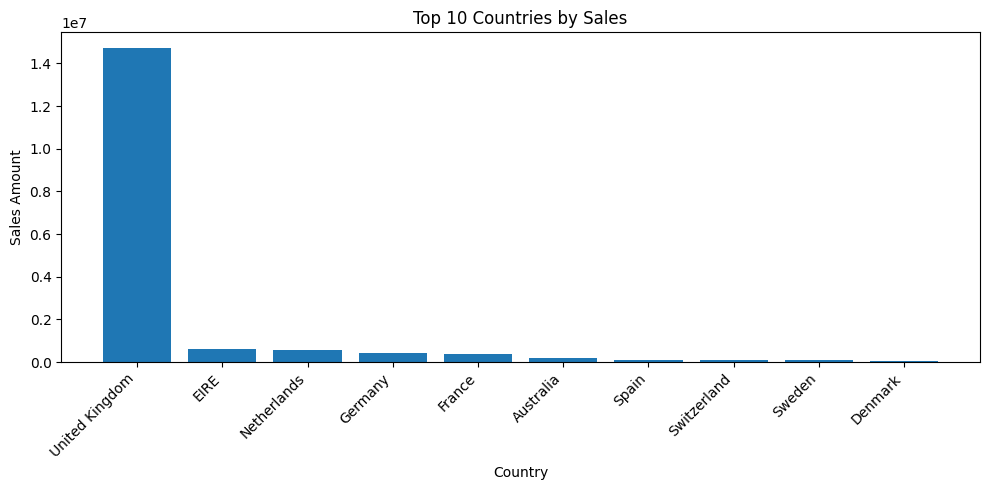

In [41]:
top10_country_sales = country_sales.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_country_sales["country"], top10_country_sales["sales_amount"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.savefig("../outputs/figures/top10_country_sales.png", dpi=150, bbox_inches="tight")
plt.show()

Top10 product sales

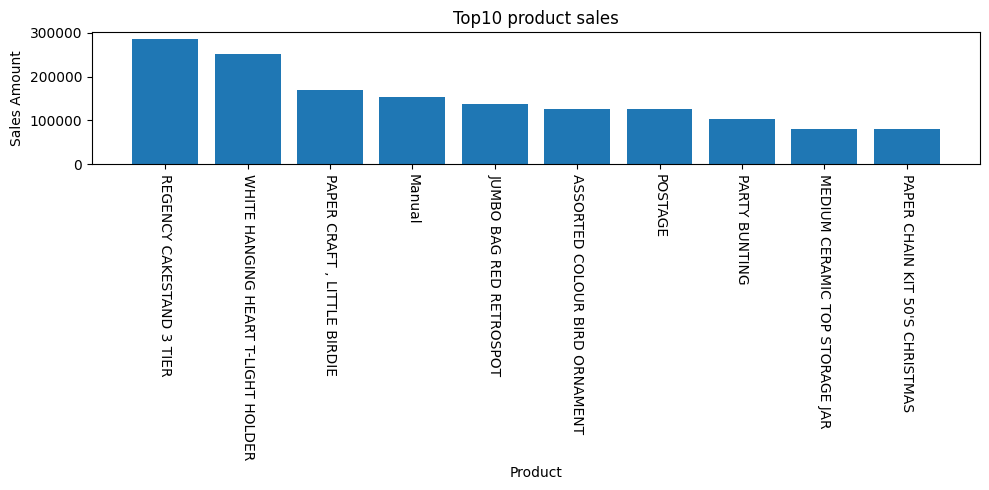

In [42]:
plt.figure(figsize=(10, 5))
plt.bar(product_sales.head(10)["description"], product_sales.head(10)["sales_amount"])
plt.xticks(rotation=270)
plt.title("Top10 product sales")
plt.xlabel("Product")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.savefig("../outputs/figures/top10_product_sales.png", dpi=150, bbox_inches="tight")
plt.show()

Customer total sales distribution

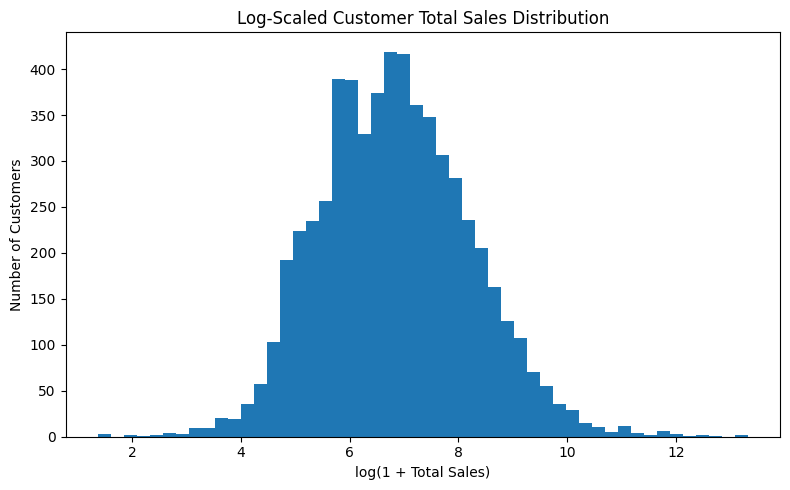

In [43]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(customer_summary["total_sales"]), bins=50)
plt.title("Log-Scaled Customer Total Sales Distribution")
plt.xlabel("log(1 + Total Sales)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../outputs/figures/Log-Scaled_customer_total_sales_distribution.png", dpi=150, bbox_inches="tight")
plt.show()